1.Business Objective
El objetivo es identificar segmentos de clientes mediante técnicas de aprendizaje no supervisado para apoyar estrategias de marketing, retención y generación de ingresos.

In [6]:
#2. Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
pd.set_option('display.max_columns', None)

In [7]:
#3. Carga y unión de datasets
ruta_archivo = r"C:\Users\usuario\Desktop\Proyectos importantes\Retail Customer Intelligence Customer Segmentation through Unsupervised Machine Learning\data\raw\online_retail_II.xlsx"



df_09_10 = pd.read_excel(ruta_archivo, sheet_name="Year 2009-2010")
df_10_11 = pd.read_excel(ruta_archivo, sheet_name="Year 2010-2011")


df = pd.concat([df_09_10, df_10_11], ignore_index=True)

In [8]:
#4. Dimensión del dataset
df.shape

(1067371, 8)

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
530614,536846,22367,CHILDRENS APRON SPACEBOY DESIGN,2,2010-12-02 19:59:00,1.95,14573.0,United Kingdom
516418,537434,22095,LADS ONLY TISSUE BOX,1,2010-12-06 16:57:00,2.51,NaN,United Kingdom
465035,533311,79191D,RETRO PLASTIC DAISY TRAY,5,2010-11-16 17:03:00,0.85,16904.0,United Kingdom
770166,558540,22727,ALARM CLOCK BAKELIKE RED,12,2011-06-30 12:15:00,3.75,17706.0,United Kingdom
211521,509914,21240,BLUE SPOTTY CUP,16,2010-05-26 11:31:00,0.85,17685.0,United Kingdom


In [11]:
#5. Calidad de datos
df.isnull().sum()
(df.isnull().mean()*100).sort_values(ascending=False)

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

# 6. Missing Values Analysis

The dataset contains missing values primarily in the `Customer ID` column. Since the objective of this project is customer segmentation, customer identifiers are essential to build customer-level behavioral features such as Recency, Frequency, and Monetary value.

At this stage, missing values are analyzed but not yet removed, as the impact on the dataset must first be quantified.


In [12]:
missing_customer = df["Customer ID"].isna().sum()

print(f"Records without Customer ID: {missing_customer:,}")
print(f"Percentage of missing Customer IDs: {(missing_customer / len(df))*100:.2f}%")


Records without Customer ID: 243,007
Percentage of missing Customer IDs: 22.77%


# 7. Quantity Analysis

This section explores the distribution and statistical properties of transaction quantities.

Negative quantities may indicate:
- Product returns
- Order cancellations
- Refund transactions

Understanding these records is critical before data cleaning and feature engineering.


In [13]:
df["Quantity"].describe()

count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64

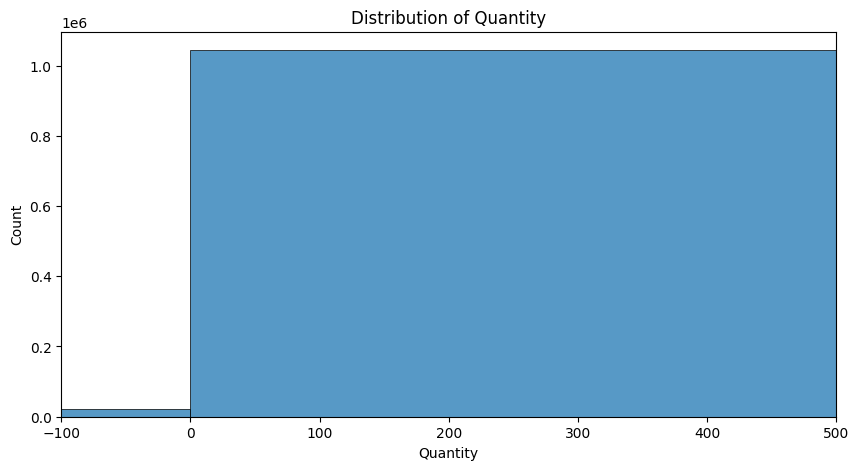

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["Quantity"], bins=100)

plt.title("Distribution of Quantity")
plt.xlim(-100, 500)
plt.show()


# 8. Price Analysis

This section evaluates product prices and identifies potential anomalies such as:
- Zero prices
- Negative prices
- Extreme outliers

These records may represent promotions, manual adjustments, or data inconsistencies.


In [15]:
df["Price"].describe()

count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64

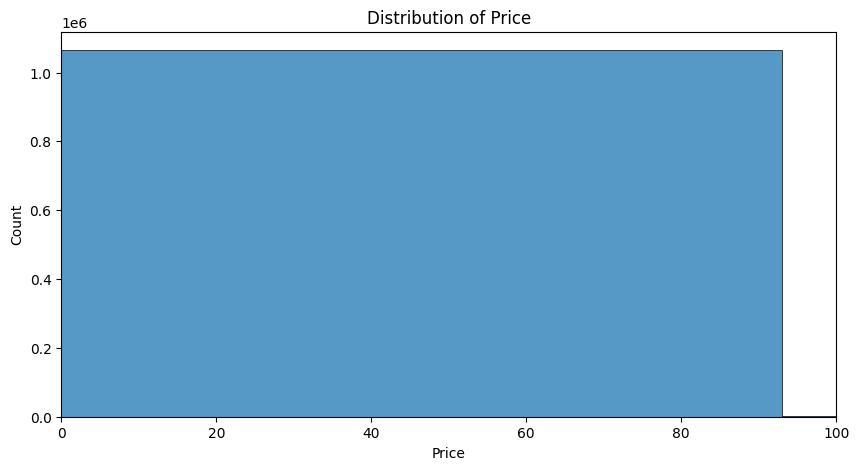

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price"], bins=100)

plt.title("Distribution of Price")
plt.xlim(0, 100)
plt.show()


# 9. Cancellation and Return Analysis

Invoices beginning with the letter `C` generally represent cancelled transactions.

This section quantifies:
- Cancelled invoices
- Negative quantities
- Non-positive prices

These metrics will help define the final data-cleaning strategy.


In [17]:
cancelled_invoices = df["Invoice"].astype(str).str.startswith("C").sum()

negative_quantities = (df["Quantity"] < 0).sum()

non_positive_prices = (df["Price"] <= 0).sum()

print(f"Cancelled invoices: {cancelled_invoices:,}")
print(f"Negative quantities: {negative_quantities:,}")
print(f"Non-positive prices: {non_positive_prices:,}")


Cancelled invoices: 19,494
Negative quantities: 22,950
Non-positive prices: 6,207


# 10. Geographic Distribution

Understanding the geographic concentration of customers helps contextualize the retail business and customer base.


In [18]:
top_countries = df["Country"].value_counts().head(10)

top_countries


Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

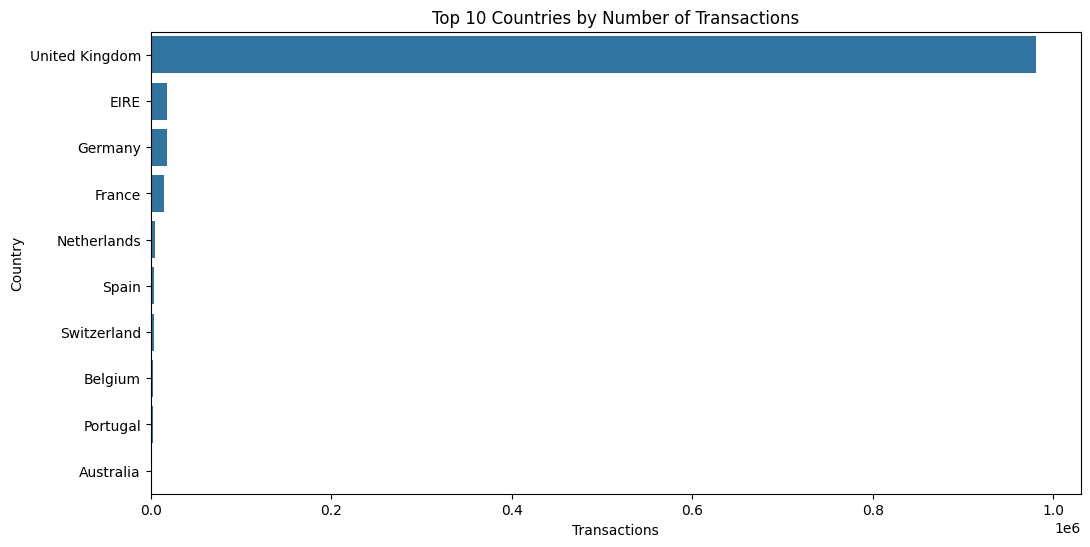

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Transactions")
plt.ylabel("Country")

plt.show()


# 11. Temporal Analysis

This section analyzes the evolution of transactions over time to identify:
- Growth trends
- Seasonality
- Peaks in purchasing behavior


In [20]:
monthly_transactions = (
    df.groupby(
        pd.Grouper(key="InvoiceDate", freq="ME")
    )
    .size()
)


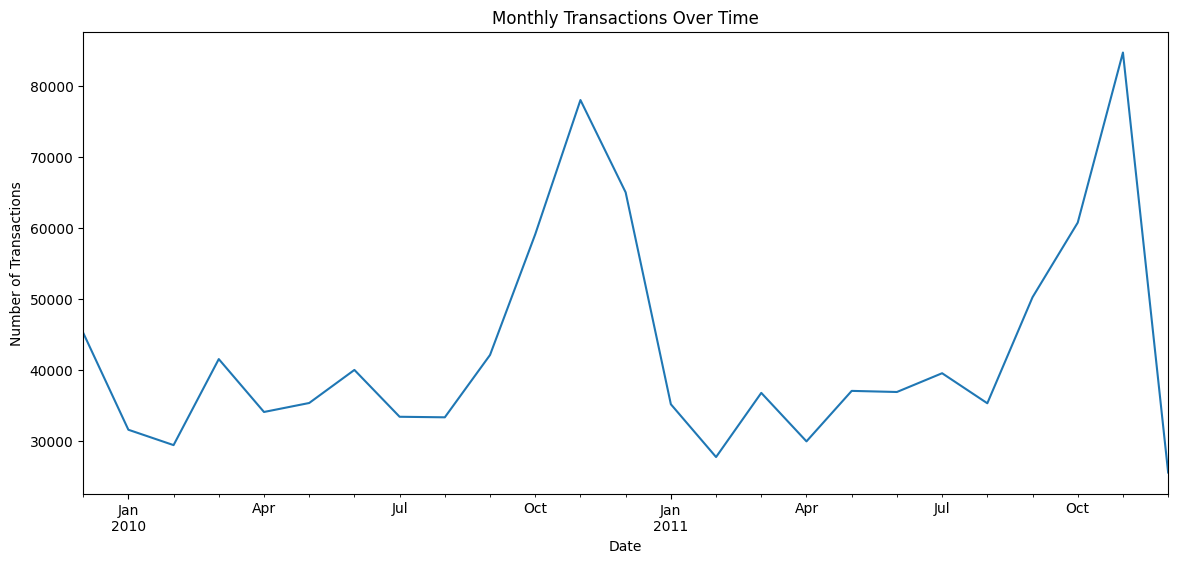

In [21]:
plt.figure(figsize=(14,6))

monthly_transactions.plot()

plt.title("Monthly Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.show()


# 12. Unique Customers

The number of unique customers provides an estimate of the effective population available for customer segmentation.


In [22]:
df["Customer ID"].nunique()

5942

# 13. Initial EDA Conclusions

## Key Findings

- The dataset contains more than one million transaction records.
- Approximately 22.77% of transactions have missing customer identifiers.
- The dataset includes negative quantities, likely associated with returns or cancellations.
- Some transactions contain zero or non-positive prices.
- The business is heavily concentrated in the United Kingdom.
- The transactional history spans approximately two years.
- The dataset contains thousands of unique customers, making it suitable for customer segmentation.

## Next Steps

The next notebook will focus on:
1. Data cleaning
2. Handling cancellations and invalid transactions
3. Feature engineering using RFM metrics
4. Preparing the dataset for clustering algorithms


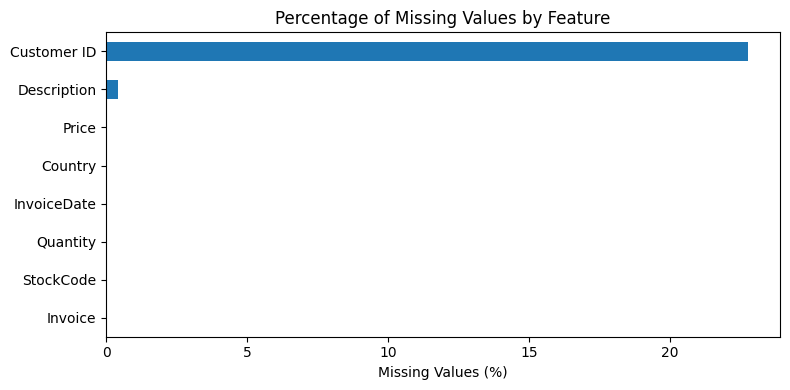

In [23]:
missing_pct = (df.isnull().mean()*100).sort_values(ascending=True)

plt.figure(figsize=(8,4))
missing_pct.plot(kind="barh")
plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.tight_layout()
plt.show()